# CMS Medicare Plan Data Exploration
exploring 3 months of CPSC data (dec 2025, jan 2026, feb 2026) to understand change patterns and data quality signals

In [1]:
# setup
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 200)

In [5]:
# loading contract files
c_dec = pd.read_csv('/Users/aashnijoshi/Downloads/chapter-data-monitor/data/CPSC_Contract_Info_2025_12.csv', encoding='latin-1')
c_jan = pd.read_csv('/Users/aashnijoshi/Downloads/chapter-data-monitor/data/CPSC_Contract_Info_2026_01.csv', encoding='latin-1')
c_feb = pd.read_csv('/Users/aashnijoshi/Downloads/chapter-data-monitor/data/CPSC_Contract_Info_2026_02.csv', encoding='latin-1')

print(f'contract rows: dec={len(c_dec)}, jan={len(c_jan)}, feb={len(c_feb)}')
print(f'\ncolumns: {list(c_dec.columns)}')
c_dec.head(3)

contract rows: dec=7863, jan=7586, feb=7592

columns: ['Contract ID', 'Plan ID', 'Organization Type', 'Plan Type', 'Offers Part D', 'SNP Plan', 'EGHP', 'Organization Name', 'Organization Marketing Name', 'Plan Name', 'Parent Organization', 'Contract Effective Date']


,Contract ID,Plan ID,Organization Type,Plan Type,Offers Part D,SNP Plan,EGHP,Organization Name,Organization Marketing Name,Plan Name,Parent Organization,Contract Effective Date
0,90091,NaN,HCPP - 1833 Cost,HCPP - 1833 Cost,No,No,No,UNITED MINE WORKERS OF AMERICA HLTH & RETIREMENT,United Mine Workers of America Health & Retire...,NaN,UMWA Health and Retirement Funds,02/01/1974
1,E3014,801.0,Employer/Union Only Direct Contract PDP,Employer/Union Only Direct Contract PDP,Yes,No,Yes,PSERS HOP PROGRAM,Pennsylvania Public School Employees Retiremen...,PSERS Health Options Program (Employer PDP),Commonwealth of PA Pub Schools Retirement System,01/01/2007
2,E3014,802.0,Employer/Union Only Direct Contract PDP,Employer/Union Only Direct Contract PDP,Yes,No,Yes,PSERS HOP PROGRAM,Pennsylvania Public School Employees Retiremen...,PSERS Health Options Program Value (Employer PDP),Commonwealth of PA Pub Schools Retirement System,01/01/2007


In [6]:
# loading enrollment files
e_dec = pd.read_csv('/Users/aashnijoshi/Downloads/chapter-data-monitor/data/CPSC_Enrollment_Info_2025_12.csv', encoding='latin-1')
e_jan = pd.read_csv('/Users/aashnijoshi/Downloads/chapter-data-monitor/data/CPSC_Enrollment_Info_2026_01.csv', encoding='latin-1')
e_feb = pd.read_csv('/Users/aashnijoshi/Downloads/chapter-data-monitor/data/CPSC_Enrollment_Info_2026_02.csv', encoding='latin-1')

print(f'enrollment rows: dec={len(e_dec)}, jan={len(e_jan)}, feb={len(e_feb)}')
print(f'\ncolumns: {list(e_dec.columns)}')
e_dec.head(3)

enrollment rows: dec=3660916, jan=3397382, feb=3393163

columns: ['Contract Number', 'Plan ID', 'SSA State County Code', 'FIPS State County Code', 'State', 'County', 'Enrollment']


,Contract Number,Plan ID,SSA State County Code,FIPS State County Code,State,County,Enrollment
0,E3014,801,2066,NaN,NaN,NaN,*
1,E3014,801,2195,NaN,NaN,NaN,*
2,E3014,801,2105,NaN,NaN,NaN,*


## first look: enrollment data is mostly masked, but not entirely

~3.2M out of ~3.4M rows (94.6%) have enrollment masked as `*` — CMS suppresses small counts for privacy. but ~185K rows have actual numeric enrollment values. this means we can do *some* enrollment analysis for larger plans/counties.

also: ~10,400 rows have no State or County info (NaN) but still have SSA/FIPS codes. these appear to be plans with geographic codes that don't map to a named state/county — likely territories, or plans with non-standard service areas. a plan matcher needs to handle these edge cases.

In [7]:
# confirming enrollment masking and checking for any real values
print('enrollment value distribution (jan):')
print(e_jan['Enrollment'].value_counts())

# checking the NaN situation in geographic fields
print(f'\njan enrollment rows with NaN state: {e_jan["State"].isna().sum()} out of {len(e_jan)}')
print(f'jan enrollment rows with NaN county: {e_jan["County"].isna().sum()} out of {len(e_jan)}')
print(f'\nsample rows with NaN state:')
e_jan[e_jan['State'].isna()].head(5)

enrollment value distribution (jan):
Enrollment
*        3212695
11          5219
12          4691
13          4347
14          4006
          ...   
6809           1
24244          1
2723           1
3841           1
14723          1
Name: count, Length: 5370, dtype: int64

jan enrollment rows with NaN state: 10404 out of 3397382
jan enrollment rows with NaN county: 10404 out of 3397382

sample rows with NaN state:


,Contract Number,Plan ID,SSA State County Code,FIPS State County Code,State,County,Enrollment
0,E3014,801,2198,NaN,NaN,NaN,*
1,E3014,801,2275,NaN,NaN,NaN,*
2,E3014,801,2105,NaN,NaN,NaN,*
3,E3014,801,2195,NaN,NaN,NaN,*
4,E3014,801,2063,NaN,NaN,NaN,*


In [8]:
# separating masked vs real enrollment values
e_jan_real = e_jan[e_jan['Enrollment'] != '*'].copy()
e_jan_real['Enrollment'] = e_jan_real['Enrollment'].astype(int)

print(f'rows with real enrollment data: {len(e_jan_real):,} out of {len(e_jan):,} ({len(e_jan_real)/len(e_jan)*100:.1f}%)')
print(f'rows masked: {(e_jan["Enrollment"] == "*").sum():,} ({(e_jan["Enrollment"] == "*").sum()/len(e_jan)*100:.1f}%)')

print(f'\nenrollment stats (non-masked rows):')
print(e_jan_real['Enrollment'].describe())

print(f'\ntop 10 largest enrollment counts (single plan in single county):')
top = e_jan_real.nlargest(10, 'Enrollment')[['Contract Number', 'Plan ID', 'State', 'County', 'Enrollment']]
print(top.to_string(index=False))

rows with real enrollment data: 184,687 out of 3,397,382 (5.4%)
rows masked: 3,212,695 (94.6%)

enrollment stats (non-masked rows):
count    184687.000000
mean        322.003460
std        1486.447641
min          11.000000
25%          24.000000
50%          60.000000
75%         192.000000
max      178107.000000
Name: Enrollment, dtype: float64

top 10 largest enrollment counts (single plan in single county):
Contract Number  Plan ID State      County  Enrollment
          H0524        3    CA Los Angeles      178107
          S4802       94    CA Los Angeles      136729
          S5617      158    CA Los Angeles      110574
          S4802      134    AZ    Maricopa       94308
          H0524      805    CA Los Angeles       93054
          S4802      151    IL        Cook       80270
          S4802       87    IL        Cook       80254
          H5425        6    CA Los Angeles       79925
          S4802      163    CA Los Angeles       75136
          H0524       37    CA   Sa

## plan year transition: dec → jan
jan 1 is when new plan year starts. expecting big churn — contracts terminating, new ones launching

In [9]:
# unique contract+plan combos per month
def get_plan_ids(df, contract_col='Contract ID', plan_col='Plan ID'):
    return set(zip(df[contract_col], df[plan_col]))

plans_dec = get_plan_ids(c_dec)
plans_jan = get_plan_ids(c_jan)
plans_feb = get_plan_ids(c_feb)

print(f'unique plans: dec={len(plans_dec)}, jan={len(plans_jan)}, feb={len(plans_feb)}')
print(f'\ndec → jan:')
print(f'  removed: {len(plans_dec - plans_jan)}')
print(f'  added:   {len(plans_jan - plans_dec)}')
print(f'  stable:  {len(plans_dec & plans_jan)}')
print(f'\njan → feb:')
print(f'  removed: {len(plans_jan - plans_feb)}')
print(f'  added:   {len(plans_feb - plans_jan)}')
print(f'  stable:  {len(plans_jan & plans_feb)}')

unique plans: dec=7863, jan=7586, feb=7592

dec → jan:
  removed: 1428
  added:   1151
  stable:  6435

jan → feb:
  removed: 5
  added:   11
  stable:  7581


In [10]:
# unique contracts (ignoring plan id) per month
contracts_dec = set(c_dec['Contract ID'])
contracts_jan = set(c_jan['Contract ID'])
contracts_feb = set(c_feb['Contract ID'])

print(f'unique contracts: dec={len(contracts_dec)}, jan={len(contracts_jan)}, feb={len(contracts_feb)}')
print(f'\ndec → jan:')
print(f'  contracts removed: {len(contracts_dec - contracts_jan)}')
print(f'  contracts added:   {len(contracts_jan - contracts_dec)}')
print(f'\njan → feb:')
print(f'  contracts removed: {len(contracts_jan - contracts_feb)}')
print(f'  contracts added:   {len(contracts_feb - contracts_jan)}')

unique contracts: dec=982, jan=973, feb=976

dec → jan:
  contracts removed: 80
  contracts added:   71

jan → feb:
  contracts removed: 0
  contracts added:   3


In [11]:
# who left? which orgs lost contracts dec → jan
removed_dec_jan = contracts_dec - contracts_jan
removed_contracts = c_dec[c_dec['Contract ID'].isin(removed_dec_jan)]

print(f'contracts removed dec → jan: {len(removed_dec_jan)}')
print(f'\ntop parent orgs losing contracts:')
print(removed_contracts['Parent Organization'].value_counts().head(15))

contracts removed dec → jan: 80

top parent orgs losing contracts:
Parent Organization
Humana Inc.                                     39
The Carle Foundation                            34
Centene Corporation                             29
UCare Minnesota                                 17
Sentara Health Care (SHC)                       17
University of Michigan Health                   15
Health Care Service Corporation                 13
Louisiana Health Service & Indemnity Company    10
Lumeris Group Holdings Corporation              10
UnitedHealth Group, Inc.                         9
Medica Holding Company                           9
Elevance Health, Inc.                            9
CVS Health Corporation                           7
USAble Mutual Insurance Company                  7
Ochsner Clinic Foundation                        5
Name: count, dtype: int64


## who's churning
humana leads in raw contract removals (39), but they're also the second-largest carrier with 1,086 plans. the more interesting signal is that the top 5 parent orgs (humana, carle foundation, centene, ucare, sentara) account for the majority of removals. 

for chapter, this means plan freshness monitoring isn't uniform — certain carriers require more aggressive data validation around the plan year transition. a carrier-level reliability score would help prioritize which data feeds to check first.

In [12]:
# what types of plans were removed?
print('plan types removed dec → jan:')
print(removed_contracts['Plan Type'].value_counts())
print(f'\norg types removed:')
print(removed_contracts['Organization Type'].value_counts())

plan types removed dec → jan:
Plan Type
HMO/HMOPOS                           148
Local PPO                             77
Medicare-Medicaid Plan HMO/HMOPOS     27
Medicare Prescription Drug Plan        8
Regional PPO                           1
Name: count, dtype: int64

org types removed:
Organization Type
Local CCP                          225
Demo                                27
Medicare Prescription Drug Plan      8
Regional CCP                         1
Name: count, dtype: int64


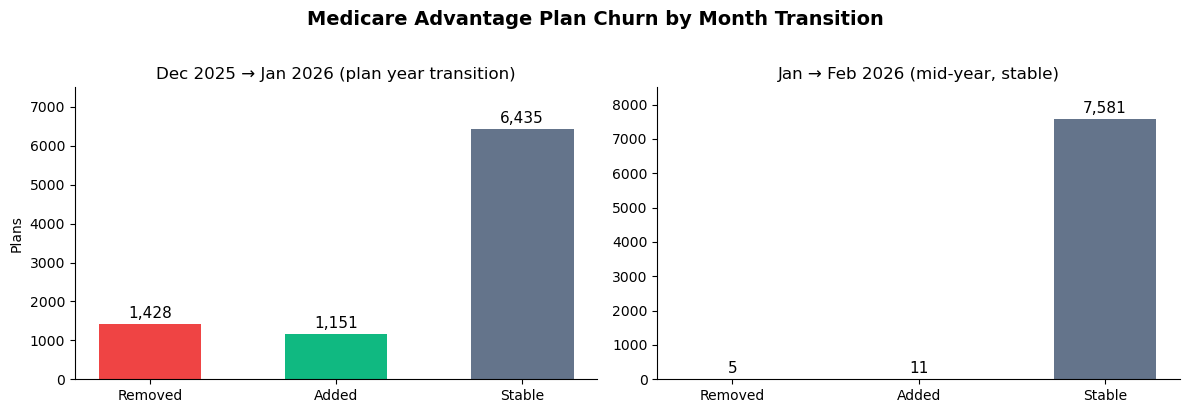

In [22]:
# visualizing plan year churn
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 1]})

# dec → jan
cats_1 = ['Removed', 'Added', 'Stable']
vals_1 = [1428, 1151, 6435]
colors_1 = ['#EF4444', '#10B981', '#64748B']
bars_1 = axes[0].bar(cats_1, vals_1, color=colors_1, edgecolor='none', width=0.55)
for bar, val in zip(bars_1, vals_1):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80, f'{val:,}',
                 ha='center', va='bottom', fontsize=11, fontweight='medium')
axes[0].set_title('Dec 2025 → Jan 2026 (plan year transition)', fontsize=12, fontweight='medium')
axes[0].set_ylabel('Plans')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_ylim(0, 7500)

# jan → feb
cats_2 = ['Removed', 'Added', 'Stable']
vals_2 = [5, 11, 7581]
colors_2 = ['#EF4444', '#10B981', '#64748B']
bars_2 = axes[1].bar(cats_2, vals_2, color=colors_2, edgecolor='none', width=0.55)
for bar, val in zip(bars_2, vals_2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80, f'{val:,}',
                 ha='center', va='bottom', fontsize=11, fontweight='medium')
axes[1].set_title('Jan → Feb 2026 (mid-year, stable)', fontsize=12, fontweight='medium')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_ylim(0, 8500)

plt.suptitle('Medicare Advantage Plan Churn by Month Transition', fontsize=14, fontweight='semibold', y=1.02)
plt.tight_layout()
plt.show()

## plan renames
plans that exist in both months but changed their name — could break name-based matching

In [13]:
# finding plan renames between months
def find_renames(df_old, df_new, label):
    merged = df_old.merge(df_new, on=['Contract ID', 'Plan ID'], suffixes=('_old', '_new'))
    renames = merged[merged['Plan Name_old'] != merged['Plan Name_new']]
    print(f'{label}: {len(renames)} plan renames')
    if len(renames) > 0:
        print(renames[['Contract ID', 'Plan ID', 'Plan Name_old', 'Plan Name_new', 'Parent Organization_old']].head(15))
    return renames

renames_dj = find_renames(c_dec, c_jan, 'dec → jan')
print()
renames_jf = find_renames(c_jan, c_feb, 'jan → feb')

dec → jan: 1197 plan renames
    Contract ID  Plan ID                                      Plan Name_old                                      Plan Name_new                           Parent Organization_old
0         90091      NaN                                                NaN                                                NaN                  UMWA Health and Retirement Funds
1         E3014    801.0        PSERS Health Options Program (Employer PDP)   PSERS Health Options Program Plus (Employer PDP)  Commonwealth of PA Pub Schools Retirement System
2         E3014    802.0  PSERS Health Options Program Value (Employer PDP)  PSERS Health Options Program Standard (Employe...  Commonwealth of PA Pub Schools Retirement System
33        H0028     63.0          Humana Gold Plus Giveback H0028-063 (HMO)    Humana Essentials Plus Giveback H0028-063 (HMO)                                       Humana Inc.
48        H0029      7.0              Wellcare Dual Liberty (HMO-POS D-SNP)         We

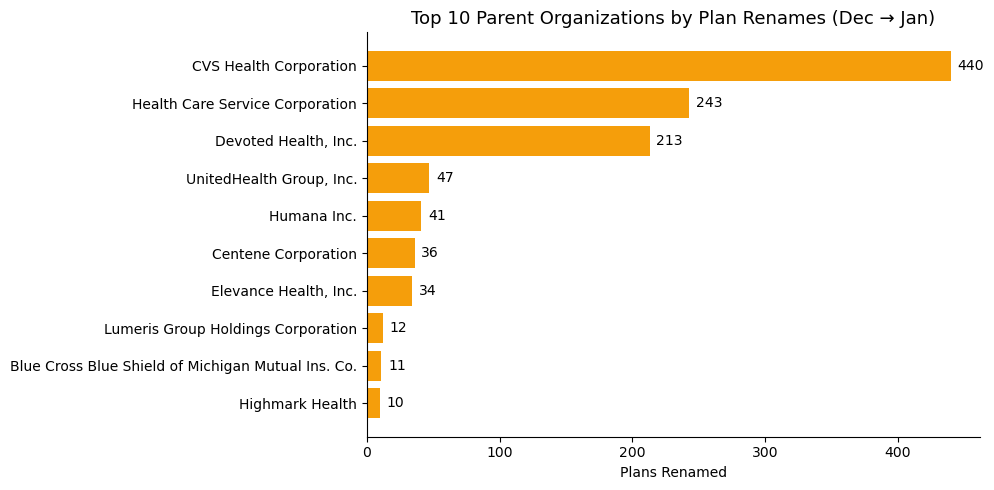

In [24]:
# visualizing plan renames by parent org
rename_by_parent = renames_dj.groupby('Parent Organization_old').size().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(rename_by_parent.index[::-1], rename_by_parent.values[::-1], color='#F59E0B', edgecolor='none')

for i, (val, name) in enumerate(zip(rename_by_parent.values[::-1], rename_by_parent.index[::-1])):
    ax.text(val + 5, i, str(val), va='center', fontsize=10)

ax.set_xlabel('Plans Renamed')
ax.set_title('Top 10 Parent Organizations by Plan Renames (Dec → Jan)', fontsize=13, fontweight='medium')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## why renames matter for plan matching
1,197 plan renames in a single month transition — that's 1 in 6 plans changing their display name. this isn't just cosmetic. look at contract H0354: every Cigna-branded plan became HealthSpring under Health Care Service Corporation. that's a full carrier rebrand.

if chapter's copilot shows an advisor "Cigna Preferred Medicare (HMO)" and the plan is now called "HealthSpring Preferred (HMO)", the advisor loses trust. if any matching logic keys on plan name strings, it breaks silently.

chapter needs a plan identity layer that tracks plans by contract ID + plan ID (which are stable) rather than relying on display names (which clearly aren't).

## parent organization analysis
which carriers are the biggest? most stable? most volatile?

In [14]:
# top parent orgs by plan count (jan 2026)
print('top 20 parent organizations by plan count (jan 2026):')
print(c_jan['Parent Organization'].value_counts().head(20))

top 20 parent organizations by plan count (jan 2026):
Parent Organization
UnitedHealth Group, Inc.                              1251
Humana Inc.                                           1086
CVS Health Corporation                                 768
Elevance Health, Inc.                                  496
Health Care Service Corporation                        434
Devoted Health, Inc.                                   416
Centene Corporation                                    375
Kaiser Foundation Health Plan, Inc.                    158
Highmark Health                                        111
Alignment Healthcare USA, LLC                          100
SCAN Group                                              98
Guidewell Mutual Holding Corporation                    90
Trinity Health Corporation                              67
Molina Healthcare, Inc.                                 62
Blue Cross Blue Shield of Michigan Mutual Ins. Co.      59
Medica Holding Company                   

In [15]:
# stability: which orgs had plans in all 3 months vs only some
all_three = plans_dec & plans_jan & plans_feb
only_dec = plans_dec - plans_jan - plans_feb
only_jan = (plans_jan - plans_dec) & (plans_jan - plans_feb)  # appeared in jan, gone by feb

print(f'plans present all 3 months: {len(all_three)}')
print(f'plans only in dec (terminated): {len(only_dec)}')
print(f'plans only in jan (appeared then vanished): {len(only_jan)}')

# which orgs have the most unstable plans?
unstable_ids = only_dec | only_jan
unstable = c_dec[c_dec.apply(lambda r: (r['Contract ID'], r['Plan ID']) in unstable_ids, axis=1)]
print(f'\ntop orgs with unstable plans:')
print(unstable['Parent Organization'].value_counts().head(10))

plans present all 3 months: 6435
plans only in dec (terminated): 1428
plans only in jan (appeared then vanished): 5

top orgs with unstable plans:
Parent Organization
CVS Health Corporation             236
Health Care Service Corporation    178
UnitedHealth Group, Inc.           165
Humana Inc.                        146
Elevance Health, Inc.              111
Centene Corporation                110
The Carle Foundation                34
Sentara Health Care (SHC)           32
Highmark Health                     29
Molina Healthcare, Inc.             28
Name: count, dtype: int64


## geographic coverage
using enrollment files to see which states/counties each plan covers

In [16]:
# state-level coverage per month
def state_coverage(df):
    return df.groupby('State').agg(
        counties=('County', 'nunique'),
        plans=('Contract Number', 'nunique')
    ).sort_values('counties', ascending=False)

states_dec = state_coverage(e_dec)
states_jan = state_coverage(e_jan)
states_feb = state_coverage(e_feb)

print(f'states with coverage: dec={len(states_dec)}, jan={len(states_jan)}, feb={len(states_feb)}')
print(f'\ntop 15 states by county coverage (jan 2026):')
print(states_jan.head(15))

states with coverage: dec=56, jan=56, feb=56

top 15 states by county coverage (jan 2026):
       counties  plans
State                 
TX          254    528
GA          159    424
VA          136    414
KY          120    335
MO          115    356
KS          105    282
IL          102    403
NC          100    442
IA           99    286
TN           95    394
NE           93    251
IN           92    361
OH           88    389
MN           87    345
MI           83    400


### geographic coverage: wide but uneven
56 states/territories have MA coverage across all 3 months — the count is stable. but coverage depth varies wildly. texas has plans in all 254 of its counties. california has only 58 counties but contains the highest-enrollment plan-county combinations in the entire dataset.

this is an important distinction for a plan matcher: **coverage breadth** (how many counties have at least one plan) is stable month-to-month. the churn is happening in **coverage depth** (which specific plans are available in each county). a senior in rural texas technically has coverage, but their plan options may have just been cut in half by the plan year transition.

In [26]:
# coverage breadth vs depth: county count is stable, but plan options per state shift
plans_per_state_dec = e_dec.groupby('State')['Contract Number'].nunique().rename('dec_plans')
plans_per_state_jan = e_jan.groupby('State')['Contract Number'].nunique().rename('jan_plans')

state_compare = pd.concat([plans_per_state_dec, plans_per_state_jan], axis=1).dropna()
state_compare['delta'] = state_compare['jan_plans'] - state_compare['dec_plans']
state_compare['delta_pct'] = (state_compare['delta'] / state_compare['dec_plans'] * 100).round(1)

print('states with biggest plan count DROPS (dec → jan):')
print(state_compare.sort_values('delta').head(10).to_string())
print(f'\nstates with biggest plan count GAINS (dec → jan):')
print(state_compare.sort_values('delta').tail(10).to_string())

states with biggest plan count DROPS (dec → jan):
       dec_plans  jan_plans  delta  delta_pct
State                                        
SC           418        387    -31       -7.4
IL           433        403    -30       -6.9
OK           349        325    -24       -6.9
PA           436        413    -23       -5.3
OH           410        389    -21       -5.1
MT           266        246    -20       -7.5
DE           272        252    -20       -7.4
MI           419        400    -19       -4.5
IA           305        286    -19       -6.2
NE           269        251    -18       -6.7

states with biggest plan count GAINS (dec → jan):
       dec_plans  jan_plans  delta  delta_pct
State                                        
MA           361        362      1        0.3
VA           413        414      1        0.2
GU            85         87      2        2.4
CA           553        555      2        0.4
AS            72         75      3        4.2
AK           233        2

## the coverage paradox: same counties, fewer choices
county-level coverage didn't change between months — every state kept the same number of counties with at least one MA plan. but the number of plan *options* within those counties dropped significantly in several states.

south carolina lost 31 plans (-7.4%), illinois lost 30 (-6.9%), montana lost 20 (-7.5%). meanwhile florida *gained* 8 plans and california gained 2. the market is contracting in the midwest and southeast while holding steady or growing in florida and california — consistent with carriers retreating from lower-margin rural markets while protecting high-enrollment urban ones.

for a plan matcher, this means the recommendation set just got smaller in states like SC, IL, and MT. fewer options means each remaining plan carries more weight in the matching algorithm — and getting the data right on those plans matters even more.

## enrollment masking check
confirming the enrollment values are masked — and checking if any are actually numeric

In [19]:
# checking enrollment values
print('enrollment value distribution (jan):')
print(e_jan['Enrollment'].value_counts().head(10))

# any non-masked values?
non_masked = e_jan[e_jan['Enrollment'] != '*']
print(f'\nnon-masked enrollment rows: {len(non_masked)} out of {len(e_jan)}')
if len(non_masked) > 0:
    print(non_masked.head(10))

enrollment value distribution (jan):
Enrollment
*     3212695
11       5219
12       4691
13       4347
14       4006
15       3755
16       3478
17       3246
18       3045
19       2937
Name: count, dtype: int64

non-masked enrollment rows: 184687 out of 3397382
    Contract Number  Plan ID  SSA State County Code  FIPS State County Code State       County Enrollment
104           E3014      801                   3060                  4013.0    AZ     Maricopa         59
107           E3014      801                   3090                  4019.0    AZ         Pima         21
205           E3014      801                   5200                  6037.0    CA  Los Angeles         14
318           E3014      801                   8000                 10001.0    DE         Kent         20
319           E3014      801                   8010                 10003.0    DE   New Castle        115
320           E3014      801                   8020                 10005.0    DE       Sussex     

## enrollment concentration
the 5.4% of rows with real enrollment data reveals extreme geographic concentration. the top 10 plan-county combinations are almost entirely in LA county and maricopa county (phoenix). H0524 plan 3 alone has 178,107 enrollees in LA county.

for chapter, this means matching accuracy in a handful of dense counties has outsized impact. getting the recommendation wrong in LA county affects 100x more people than getting it wrong in a rural county. data freshness monitoring should be weighted by enrollment density, not treated uniformly.

## field-level changes
which columns actually change between months for plans that persist?

In [20]:
# field stability: for plans in both jan and feb, which fields changed?
merged = c_jan.merge(c_feb, on=['Contract ID', 'Plan ID'], suffixes=('_jan', '_feb'))
print(f'plans in both jan and feb: {len(merged)}')

fields = ['Organization Type', 'Plan Type', 'Offers Part D', 'SNP Plan', 'EGHP', 
          'Organization Name', 'Organization Marketing Name', 'Plan Name', 
          'Parent Organization', 'Contract Effective Date']

print(f'\nfield change rates (jan → feb):')
for field in fields:
    changed = (merged[f'{field}_jan'] != merged[f'{field}_feb']).sum()
    pct = changed / len(merged) * 100
    print(f'  {field}: {changed} changes ({pct:.2f}%)')

plans in both jan and feb: 7586

field change rates (jan → feb):
  Organization Type: 0 changes (0.00%)
  Plan Type: 0 changes (0.00%)
  Offers Part D: 0 changes (0.00%)
  SNP Plan: 0 changes (0.00%)
  EGHP: 0 changes (0.00%)
  Organization Name: 40 changes (0.53%)
  Organization Marketing Name: 0 changes (0.00%)
  Plan Name: 9 changes (0.12%)
  Parent Organization: 4 changes (0.05%)
  Contract Effective Date: 8 changes (0.11%)


## field stability: what you can trust mid-year
this is one of the cleanest findings. between jan and feb, structural fields — plan type, organization type, SNP status, Part D, EGHP — had exactly zero changes. these are locked at plan year start.

but naming fields keep shifting: 40 organization name changes, 9 plan name changes, 4 parent organization changes, 8 contract effective date changes. names are the least reliable identifier in this dataset.

**implication for chapter:** structural plan attributes (type, SNP, Part D) can be cached aggressively mid-year. name fields need continuous refresh. and any system that joins data on organization name instead of contract ID is fragile.

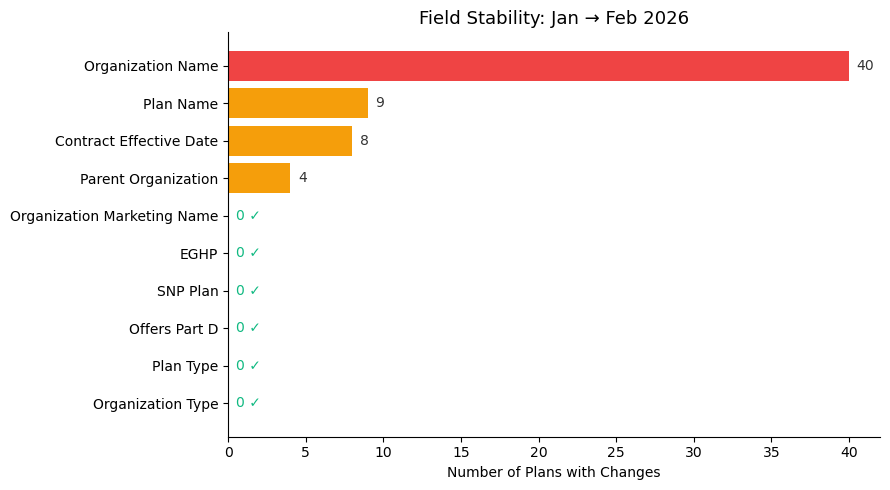

In [25]:
# visualizing field stability
fig, ax = plt.subplots(figsize=(9, 5))

fields = ['Organization Type', 'Plan Type', 'Offers Part D', 'SNP Plan', 'EGHP',
          'Organization Name', 'Organization Marketing Name', 'Plan Name',
          'Parent Organization', 'Contract Effective Date']

merged_jf = c_jan.merge(c_feb, on=['Contract ID', 'Plan ID'], suffixes=('_jan', '_feb'))
changes = []
for field in fields:
    changed = (merged_jf[f'{field}_jan'] != merged_jf[f'{field}_feb']).sum()
    changes.append(changed)

field_df = pd.DataFrame({'field': fields, 'changes': changes}).sort_values('changes', ascending=True)
colors = ['#10B981' if v == 0 else '#F59E0B' if v < 10 else '#EF4444' for v in field_df['changes']]

ax.barh(field_df['field'], field_df['changes'], color=colors, edgecolor='none')

for i, (val, name) in enumerate(zip(field_df['changes'], field_df['field'])):
    label = str(val) if val > 0 else '0 ✓'
    ax.text(val + 0.5, i, label, va='center', fontsize=10, color='#10B981' if val == 0 else '#333')

ax.set_xlabel('Number of Plans with Changes')
ax.set_title('Field Stability: Jan → Feb 2026', fontsize=13, fontweight='medium')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


## what this analysis found

i pulled 3 months of CMS Medicare Advantage plan data (dec 2025, jan 2026, feb 2026) — the same upstream data that any plan matching engine depends on — and looked at how it changes, where it breaks, and what that means for recommendation accuracy.

**1) the plan year transition is a cliff, not a slope.** 1,428 plans disappeared between december and january — 18% of the entire plan universe, gone overnight. 80 contracts terminated. 1,151 new plans appeared. this isn't unusual — but 2026 is historically elevated. KFF found that 2.6 million enrollees (13%) had their plan terminated entering 2026, double the rate from 2024. carriers are pulling back from unprofitable markets after years of margin compression. if a matching engine is working off december's data on january 2nd, it's recommending plans that no longer exist to people who just lost their coverage and are actively shopping for something new. that's the worst possible time to be wrong.

**2) 1 in 6 plans changed their name.** 1,197 plan renames in a single month. some are cosmetic (adding "Plus" or "Sync"), but others are full rebrands — every Cigna plan under contract H0354 became HealthSpring after Health Care Service Corporation reorganized their portfolio. any system that displays, searches, or matches on plan names needs to treat names as unstable identifiers. contract ID + plan ID is the only reliable key.

**3) mid-year data is remarkably stable — but only structurally.** between january and february, plan type, SNP status, Part D coverage, and organization type had exactly zero changes across 7,586 plans. but organization names changed 40 times, plan names changed 9 times, and 4 plans changed parent organizations. structural attributes can be cached aggressively mid-year. display names cannot.

**4) enrollment is concentrated in a handful of counties.** the top 10 plan-county combinations are dominated by LA county and maricopa county. a single plan (H0524-3) has 178,107 enrollees in LA county alone. matching accuracy in dense counties has outsized impact — data freshness monitoring should be weighted by enrollment volume, not treated uniformly across geographies.

**5) 94.6% of public enrollment data is masked.** CMS suppresses small enrollment counts for privacy, leaving only 5.4% of rows with real numbers. this means public data alone can't power enrollment trend analysis — but it can map geographic coverage, track plan churn, and flag structural changes. the real enrollment data likely comes through carrier feeds or CMS data use agreements.

---

*the question this raises for a plan matching system: how quickly does your data pipeline catch these changes, and how do you prioritize which ones to validate first?*
```


## what i'd investigate next

**with more time and data access:**

1. **provider directory cross-referencing** — CMS is building a national provider directory with FHIR-based APIs for CY2027. cross-referencing plan network data against actual provider directories would reveal a second layer of staleness: a plan might be "fresh" in CMS files but its provider network data could be months out of date. CMS has fined carriers for exactly this.

2. **unmasked enrollment trends** — the public CPSC data masks 94.6% of enrollment values. with access to unmasked data (via carrier feeds or CMS data use agreements), you could track enrollment migration patterns: which plans are gaining/losing members, seasonal trends during AEP vs OEP, and early warning signals for plan instability.

3. **formulary and benefit change tracking** — plan names and contract structures are one thing, but what seniors actually care about is whether their medications are covered and what they'll pay. CMS publishes quarterly formulary files that could be diffed the same way to catch drug coverage changes.

4. **automated freshness scoring** — instead of manual monthly analysis, build a pipeline that ingests each CMS data release automatically, computes a per-plan freshness score (days since last change, change frequency, deviation from carrier baseline), and flags plans that fall below a confidence threshold. the plan matcher could then weight recommendations by data confidence.

5. **plan year transition playbook** — the dec → jan churn pattern is predictable. a monitoring system could pre-stage the expected changes (which contracts are set to terminate, which new ones are approved) and validate the actual CMS data against those expectations on january 1.

---

*data sourced from CMS Medicare Advantage CPSC monthly files (dec 2025, jan 2026, feb 2026). publicly available at cms.gov.*

*built by Aashni Joshi — March 2026*